# Explainer Notebook

### Mythology vs Narrative in Warhammer 40,000 Character Network

This notebook contains the complete analysis pipeline, methodology, and findings. It demonstrates our journey from hypothesis to discovery.

## Table of Contents

2. [Data Extraction and API](#data-extraction)
3. [Network Generation: Unfiltered and Filtered Networks](#network-generation)
4. [Data Loading and Network Construction](#data-loading)
5. [Phase 1: Topological Feature Extraction](#phase1)
6. [Phase 2: Semantic Feature Extraction](#phase2)
7. [Phase 3: Hybrid Analysis - The Core Discovery](#phase3)
8. [Phase 4: Portal vs Semantic Cluster Comparison](#phase4)
9. [Phase 5: Three-Way Comparison - The Complete Picture](#phase5)
10. [Research Finding: Semantic Coherence as Explanatory Mechanism](#finding)
11. [Visualizations and Interpretations](#visualizations)
12. [Conclusion](#conclusion)


<a id='data-extraction'></a>
## 2. Data Extraction and API

### Data Extraction Methodology

The data extractyion was done from Warhammer 40K lexicanum wiki. We have from reliable reddit sources that this is more accurate than the fandom.wiki.
https://www.reddit.com/r/40kLore/comments/1hfyuhj/very_new_to_40k_how_canon_is_lexicanum_where/ <br>
https://www.reddit.com/r/40kLore/comments/13dqja7/lexicanum_vs_fandom/

From the lexicanum we created a list of characters and links between them by using Warhammer 40K Lexicanum API. 
https://wh40k.lexicanum.com/mediawiki/api.php

All code was written by an LLM.

In [1]:
from __future__ import annotations
import argparse
import json
import time
import random
from pathlib import Path
import sys

try:
    import requests
    from requests.exceptions import RequestException
except Exception:
    print('requests not found; please install requests (pip install requests)')
    raise

API_URL = "https://wh40k.lexicanum.com/mediawiki/api.php"
HEADERS = {"User-Agent": "lexicanum-page-text-extractor/1.0 (contact:example@example.com)"}
DEFAULT_SLEEP = 0.3
DEFAULT_MAX_RETRIES = 3
# backoff defaults
DEFAULT_BACKOFF_BASE = 1.0
DEFAULT_BACKOFF_FACTOR = 2.0
DEFAULT_BACKOFF_MAX = 60.0
DEFAULT_BACKOFF_JITTER = 0.1


def api_get(session, params, max_retries=None, backoff_base=DEFAULT_BACKOFF_BASE,
            backoff_factor=DEFAULT_BACKOFF_FACTOR, backoff_max=DEFAULT_BACKOFF_MAX,
            jitter=DEFAULT_BACKOFF_JITTER):
    if max_retries is None:
        max_retries = DEFAULT_MAX_RETRIES
    tries = 0
    while True:
        try:
            r = session.get(API_URL, params=params, headers=HEADERS, timeout=30)
            r.raise_for_status()
            return r.json()
        except RequestException as e:
            tries += 1
            if tries >= max_retries:
                raise
            delay = min(backoff_max, backoff_base * (backoff_factor ** (tries - 1)))
            jitter_amt = random.uniform(-jitter * delay, jitter * delay)
            sleep_time = max(0.1, delay + jitter_amt)
            print(f"Request error ({e}) — retry {tries}/{max_retries} in {sleep_time:.1f}s...")
            time.sleep(sleep_time)


def load_titles_from_crawler(input_path: Path) -> list:
    with input_path.open('r', encoding='utf-8') as fh:
        payload = json.load(fh)
    pages_by_category = payload.get('pages_by_category') or payload.get('pages_by_cat') or {}
    titles = set()
    for cat, pages in pages_by_category.items():
        for p in pages:
            t = p.get('title') if isinstance(p, dict) else p
            if t:
                titles.add(t)
    return sorted(titles)


def get_page_wikitext(session, title: str, max_retries: int, backoff_opts: dict) -> dict:
    """Return dict with pageid and wikitext (or missing flag).

    Uses 'query' + prop=revisions&rvprop=content&rvslots=main to retrieve latest wikitext.
    """
    params = {
        'action': 'query',
        'titles': title,
        'prop': 'revisions',
        'rvslots': 'main',
        'rvprop': 'content',
        'format': 'json'
    }
    data = api_get(session, params, max_retries=max_retries, **backoff_opts)
    pages = data.get('query', {}).get('pages', {})
    for page in pages.values():
        if page.get('missing') is not None:
            return {'pageid': None, 'wikitext': None, 'missing': True}
        pageid = page.get('pageid')
        revs = page.get('revisions') or []
        if revs:
            rev = revs[0]
            # MediaWiki stores content under slots->main->'*' in newer versions
            wikitext = None
            slots = rev.get('slots')
            if isinstance(slots, dict):
                wikitext = slots.get('main', {}).get('*')
            if wikitext is None:
                wikitext = rev.get('*') or rev.get('content')
            return {'pageid': pageid, 'wikitext': wikitext}
        # no revisions found
        return {'pageid': pageid, 'wikitext': None}
    return {'pageid': None, 'wikitext': None}


def main():
    parser = argparse.ArgumentParser(description='Fetch wikitext for pages listed in crawler JSON')
    parser.add_argument('--input', '-i', default='lexicanum_characters_by_category.json', help='crawler JSON file')
    #parser.add_argument('--output', '-o', default='lexicanum_page_texts.json', help='output JSON file')
    parser.add_argument('--output', '-o', default='lexicanum_page_texts_kaspertest.json', help='output JSON file')
    parser.add_argument('--limit', type=int, default=None, help='limit number of pages (for testing)')
    parser.add_argument('--start', type=int, default=0, help='start offset for batching (zero-based)')
    parser.add_argument('--max-retries', type=int, default=DEFAULT_MAX_RETRIES, help='max API attempts per request')
    parser.add_argument('--backoff-base', type=float, default=DEFAULT_BACKOFF_BASE)
    parser.add_argument('--backoff-factor', type=float, default=DEFAULT_BACKOFF_FACTOR)
    parser.add_argument('--backoff-max', type=float, default=DEFAULT_BACKOFF_MAX)
    parser.add_argument('--backoff-jitter', type=float, default=DEFAULT_BACKOFF_JITTER)
    parser.add_argument('--sleep', type=float, default=DEFAULT_SLEEP, help='polite pause between requests')
    args = parser.parse_args()

    input_path = Path(args.input)
    if not input_path.exists():
        print(f"Input file not found: {input_path}")
        sys.exit(2)

    titles = load_titles_from_crawler(input_path)
    # apply batching slice
    if args.start:
        titles = titles[args.start:]
    if args.limit:
        titles = titles[:args.limit]

    print(f"Will fetch {len(titles)} pages from {input_path}")
    session = requests.Session()

    out = {}
    backoff_opts = {
        'backoff_base': args.backoff_base,
        'backoff_factor': args.backoff_factor,
        'backoff_max': args.backoff_max,
        'jitter': args.backoff_jitter
    }

    for i, title in enumerate(titles, start=1):
        try:
            if i % 50 == 0 or i == 1:
                print(f"Progress: {i}/{len(titles)} — last: {title}")
            res = get_page_wikitext(session, title, max_retries=args.max_retries, backoff_opts=backoff_opts)
            out[title] = res
        except Exception as e:
            print(f"Failed to fetch '{title}': {e}")
            out[title] = {'pageid': None, 'wikitext': None, 'error': str(e)}
        time.sleep(args.sleep)

    payload = {
        'source': str(input_path),
        'generated': time.time(),
        'pages': out
    }
    out_path = Path(args.output)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open('w', encoding='utf-8') as fh:
        json.dump(payload, fh, ensure_ascii=False, indent=2)

    print(f"Wrote page texts to: {out_path} (pages: {len(out)})")


if __name__ == '__main__':
    main()


usage: ipykernel_launcher.py [-h] [--input INPUT] [--output OUTPUT]
                             [--limit LIMIT] [--start START]
                             [--max-retries MAX_RETRIES]
                             [--backoff-base BACKOFF_BASE]
                             [--backoff-factor BACKOFF_FACTOR]
                             [--backoff-max BACKOFF_MAX]
                             [--backoff-jitter BACKOFF_JITTER] [--sleep SLEEP]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\kkrus\AppData\Roaming\jupyter\runtime\kernel-v3b9f3643de50de0f31ce2d28100e2c9c73bd09a80.json


SystemExit: 2

C:\Users\kkrus\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3557: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)




*[This section will be written by the user to describe how the data was extracted from the Lexicanum wiki, including API details, scraping methods, data collection process, etc.]*

---





<a id='network-generation'></a>
## 3. Network Generation: Unfiltered and Filtered Networks

### Step 1: Building the Unfiltered Network

Our network construction process (`src/create_network.py`) follows a rough 5-step pipeline:

1. **Character-to-Affiliation Mapping**
   - Maps each character to their primary affiliation (wiki portals) and all affiliations
   - _all affiliations_ which contains a mix of affiliated wars, books, factions and other affiliations. 
   - Identifies race/species separately from organizational affiliations
   - Output: `character_affiliation_mapping.json`

2. **Character Entry Creation**
   - Processes all wiki pages to identify character pages
   - Filters out non-character pages (lists, formations, categories, planets, weapons, wars)
   - Extracts faction portal templates (e.g., `{{AstraMilitarumPortal}}`) from wikitext
   - Maps extracted portals to one of 16 main faction portals, supplied by manual corrections for precision and correctness
   - Assigns portal based on affiliation if not found in wikitext
   - Output: `lexicanum_characters.json`

3. **Edge Extraction**
   - Parses the character text to find wiki link patterns, ex `[[Character Name]]` indicates a link
   - Creates directed edges from source character to target character, ex name of page (character name) is the source, and links in the character text is the targets
   - Filters out portal links, special namespaces, and self-loops
   - Handles character name variations and canonicalization by stemming and manual revision
   - Output: `lexicanum_edges.json`

4. **NetworkX Graph Construction**
   - Creates directed NetworkX graph
   - Adds attributes to notes: name, affiliation, race, portals, all_affiliations
   - Adds weighted edges (multiple links between same characters increase weight)
   - Calculates basic network statistics

5. **Graph Export**
   - Exports to GEXF format (for Gephi visualization)
   - Exports to Pickle format for analysis.
   - Output: `lexicanum_network.pkl` and `lexicanum_network.gexf`

**Statistics on the Unfiltered Network:**
- **Nodes**: ~12,401 characters
- **Edges**: ~15,978 directed edges
- **Type**: Directed graph (DiGraph)
- **Contains**: All characters from the lexicanum, this includes isolated nodes with no connections.

### Step 2: Creating the Filtered Network

The filtered network (`src/create_filtered_network.py`) is created through a filtering process:

1. **Convert to Undirected for purpose of visualization**
   - Converts the directed graph to an undirected graph
   - Combines bidirectional edges into single undirected edges
   - Preserves edge weights by summing weights of combined edges

2. **Keep Largest Connected Component**
   - Identifies all connected components in the network
   - Keeps the largest connected component
   - Removes all nodes not connected to the main network to ensure unconnected (and therefore _irrelevant_) nodes doesnt affect visualization or metrics

3. **Remove Low-Degree Nodes**
   - Iteratively removes nodes with degree < 2 to reduce amount of insignificant nodes (characters )
   - This filters out peripheral characters with very few connections and therefore little impact to the story/lore

4. **Save Filtered Network**
   - Exports filtered network to Pickle format
   - Exports to GEXF format for visualization
   - Output: `lexicanum_network_filtered.pkl` and `lexicanum_network_filtered.gexf`

**Filtered Network Statistics:**
- **Nodes**: 3,232 characters (74% reduction)
- **Edges**: 8,973 edges (44% reduction)



<a id='data-loading'></a>
## 4. Data Loading and Network Construction

### Loading the Filtered Network for Analysis

We use the **filtered network** to explore our topic of Mythological vs Book narrative


In [3]:
# Import libraries
import json
import pickle
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load configuration
import sys
sys.path.append('src')
from config import DATA_PATH, PICKLE_FILTERED_FILE


In [4]:
# Load the filtered network
print("Loading filtered network...")
with open(PICKLE_FILTERED_FILE, 'rb') as f:
    G_filtered = pickle.load(f)

print(f"Network loaded: {G_filtered.number_of_nodes()} nodes, {G_filtered.number_of_edges()} edges")
print(f"Network type: {type(G_filtered).__name__}")

# Load edges to construct directed graph for analysis
with open(DATA_PATH / 'lexicanum_edges.json', 'r', encoding='utf-8') as f:
    edges_data = json.load(f)

# Get valid nodes from filtered network
valid_nodes = set(G_filtered.nodes())

# Build directed graph with only filtered nodes
G = nx.DiGraph()
for edge in edges_data:
    if edge['source'] in valid_nodes and edge['target'] in valid_nodes:
        G.add_edge(edge['source'], edge['target'])

print(f"\nDirected graph for analysis: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Loading filtered network...
Network loaded: 3232 nodes, 8973 edges
Network type: Graph

Directed graph for analysis: 3232 nodes, 11216 edges


<a id='phase1'></a>
## 3. Topological Feature Extraction

### Here we calculated 4 metrics
- **Betweenness Centrality**: Identifies bridge nodes connecting different parts of the network
- **PageRank**: Measures global importance based on incoming links
- **Clustering Coefficient**: Measures local connectivity
- **Louvain Communities**: Structural grouping based on link patterns

<a id='phase1'></a>
## 3. Topological Feature Extraction


In [5]:
# Calculate topological metrics
print("Calculating Betweenness Centrality...")
betweenness = nx.betweenness_centrality(G)

print("Calculating PageRank")
pagerank = nx.pagerank(G)

print("Calculating Clustering Coefficient")
clustering = nx.clustering(G)

# Community detection (requires undirected graph)
print("Detecting communities using Louvain algorithm")
import community.community_louvain as community_louvain
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected, random_state=42)

# Create DataFrame
topology_df = pd.DataFrame({
    'node_id': list(G.nodes()),
    'betweenness': [betweenness.get(n, 0) for n in G.nodes()],
    'pagerank': [pagerank.get(n, 0) for n in G.nodes()],
    'clustering_coefficient': [clustering.get(n, 0) for n in G.nodes()],
    'network_community_id': [partition.get(n, 0) for n in G.nodes()]
})

print(f"\nTopology metrics calculated for {len(topology_df)} nodes")
print(f"Number of network communities: {topology_df['network_community_id'].nunique()}")
print(f"\nTop 5 by Betweenness:")
print(topology_df.nlargest(5, 'betweenness')[['node_id', 'betweenness']].to_string(index=False))


Calculating Betweenness Centrality...
Calculating PageRank
Calculating Clustering Coefficient
Detecting communities using Louvain algorithm

Topology metrics calculated for 3232 nodes
Number of network communities: 38

Top 5 by Betweenness:
           node_id  betweenness
 Roboute Guilliman     0.092981
Emperor of Mankind     0.073379
        Rogal Dorn     0.046519
            Angron     0.034744
     Cato Sicarius     0.031637


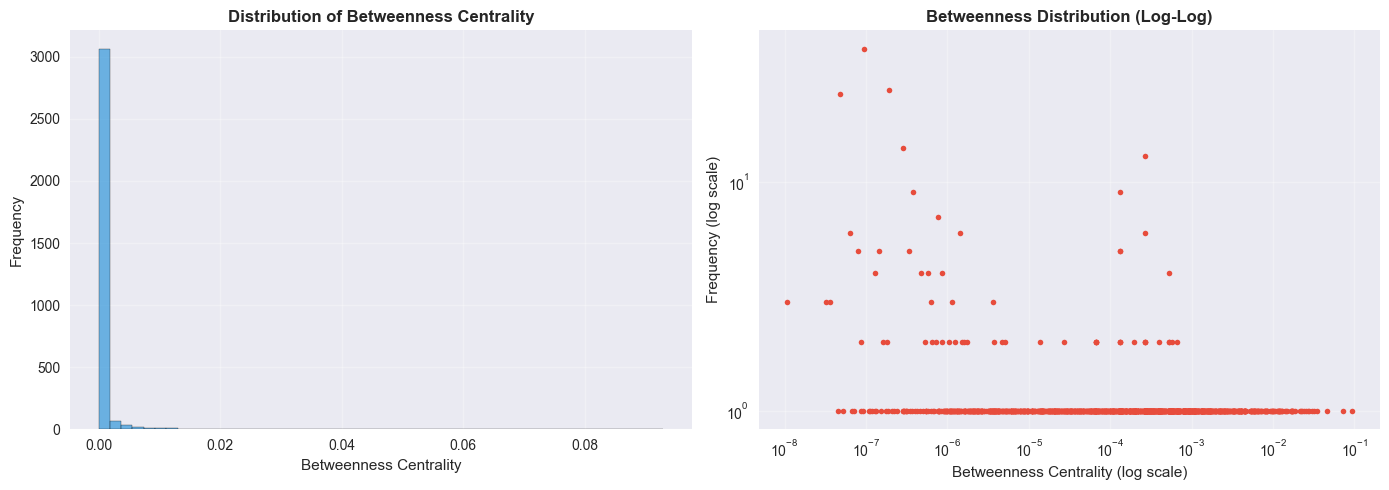


Key Observation: Highly skewed distribution with few high-betweenness nodes.
This indicates a hierarchical structure with key bridge characters.


In [6]:
# Visualize betweenness distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(topology_df['betweenness'], bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_xlabel('Betweenness Centrality', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Betweenness Centrality', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Log-log plot
betweenness_values = topology_df['betweenness'].values
betweenness_values = betweenness_values[betweenness_values > 0]  # Remove zeros for log plot
unique_values, counts = np.unique(betweenness_values, return_counts=True)
axes[1].loglog(unique_values, counts, 'o', markersize=4, color='#e74c3c')
axes[1].set_xlabel('Betweenness Centrality (log scale)', fontsize=11)
axes[1].set_ylabel('Frequency (log scale)', fontsize=11)
axes[1].set_title('Betweenness Distribution (Log-Log)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/betweenness_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey Observation: Highly skewed distribution with few high-betweenness nodes.")
print("This indicates a hierarchical structure with key bridge characters.")


In [7]:
# Calculate topological metrics
print("Calculating Betweenness Centrality...")
betweenness = nx.betweenness_centrality(G)

print("Calculating PageRank...")
pagerank = nx.pagerank(G)

print("Calculating Clustering Coefficient...")
clustering = nx.clustering(G)

# Community detection (requires undirected graph)
print("Detecting communities using Louvain algorithm...")
import community.community_louvain as community_louvain
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected, random_state=42)

# Create DataFrame
topology_df = pd.DataFrame({
    'node_id': list(G.nodes()),
    'betweenness': [betweenness.get(n, 0) for n in G.nodes()],
    'pagerank': [pagerank.get(n, 0) for n in G.nodes()],
    'clustering_coefficient': [clustering.get(n, 0) for n in G.nodes()],
    'network_community_id': [partition.get(n, 0) for n in G.nodes()]
})

print(f"\nTopology metrics calculated for {len(topology_df)} nodes")
print(f"Number of network communities: {topology_df['network_community_id'].nunique()}")
print(f"\nTop 5 by Betweenness:")
print(topology_df.nlargest(5, 'betweenness')[['node_id', 'betweenness']].to_string(index=False))


Calculating Betweenness Centrality...
Calculating PageRank...
Calculating Clustering Coefficient...
Detecting communities using Louvain algorithm...

Topology metrics calculated for 3232 nodes
Number of network communities: 38

Top 5 by Betweenness:
           node_id  betweenness
 Roboute Guilliman     0.092981
Emperor of Mankind     0.073379
        Rogal Dorn     0.046519
            Angron     0.034744
     Cato Sicarius     0.031637


<a id='phase3'></a>
## 5. Hybrid Analysis - Neighbor Semantic Consistency

For each character, we calculate the **average cosine similarity** between their text embedding and their neighbors' embeddings.

**Hypothesis**:
- **High consistency** → Narrative Agents (characters within specific story arcs)
- **Low consistency** → Mythological Anchors (characters connecting disparate parts of lore)

In [8]:
# Calculate correlation between betweenness and neighbor consistency
from scipy.stats import pearsonr

df_hybrid = df_results.dropna(subset=['betweenness', 'neighbor_consistency'])
correlation, p_value = pearsonr(df_hybrid['betweenness'], df_hybrid['neighbor_consistency'])

print(f"Correlation (Betweenness vs Neighbor Consistency): {correlation:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"\nInterpretation: {'Weak negative' if correlation < 0 else 'Weak positive'} correlation")
print("This suggests high-betweenness characters tend to have slightly lower consistency,")
print("but the relationship is not strong.")

# Identify Mythological Anchor Candidates
candidates = df_hybrid[
    (df_hybrid['betweenness'] >= 0.01) & 
    (df_hybrid['neighbor_consistency'] <= 0.50)
].sort_values('betweenness', ascending=False)

print(f"\n\nMythological Anchor Candidates (Betweenness >= 0.01, Consistency <= 0.50):")
print(f"Found {len(candidates)} candidates\n")

for idx, row in candidates.head(10).iterrows():
    print(f"{row['node_id']:40s} | Betweenness: {row['betweenness']:8.6f} | "
          f"Consistency: {row['neighbor_consistency']:.4f}")


NameError: name 'df_results' is not defined

In [ ]:
# Create the mythology scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Filter data
plot_df = df_results.dropna(subset=['betweenness', 'neighbor_consistency', 'semantic_cluster_id'])

# Create scatter plot colored by semantic cluster
scatter = ax.scatter(plot_df['betweenness'] + 1e-6, plot_df['neighbor_consistency'],
                    c=plot_df['semantic_cluster_id'], cmap='tab20', alpha=0.6, 
                    s=50, edgecolors='black', linewidth=0.5)

# Set log scale for x-axis
ax.set_xscale('log')
ax.set_xlabel('Betweenness Centrality (log scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Neighbor Semantic Consistency', fontsize=12, fontweight='bold')
ax.set_title('Mythology vs Narrative: Betweenness vs Neighbor Semantic Consistency\n' +
             '(Colored by Semantic Cluster)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Semantic Cluster ID', fontsize=11)

# Add annotation for key regions
ax.text(0.001, 0.3, 'Mythological\nAnchors', fontsize=11, bbox=dict(boxstyle='round', 
        facecolor='yellow', alpha=0.5), ha='center')
ax.text(0.0001, 0.7, 'Narrative\nAgents', fontsize=11, bbox=dict(boxstyle='round', 
        facecolor='lightgreen', alpha=0.5), ha='center')

plt.tight_layout()
plt.savefig('images/mythology_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey regions:")
print("  - Top-right: High betweenness + High consistency (important within coherent narrative)")
print("  - Top-left: Low betweenness + High consistency (local narrative agents)")
print("  - Bottom-right: High betweenness + Low consistency (mythological anchors)")


<a id='phase4'></a>
## 6. Portal vs Semantic Cluster Comparison

**We explore if the faction labels (from portals) actually match semantic themes (from clusters found by the all-miniLM-L6-v2 model)?**

The comparison reveals that some network communities don't align with faction labels.

### Discovery

- **High alignment** (ex. Adepta Sororitas 85.1%): Faction has coherent semantic identity
- **Low alignment** (ex. Space Marines 13.7%): Faction is semantically diverse


In [ ]:
# Visualize portal alignment
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(alignment_df['Portal'], alignment_df['Alignment %'], 
               alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Alignment % (Characters in Dominant Cluster)', fontsize=12, fontweight='bold')
ax.set_ylabel('Portal (Faction)', fontsize=12, fontweight='bold')
ax.set_title('Portal Alignment with Semantic Clusters\n' +
             '(How well do faction labels match semantic themes?)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, align) in enumerate(zip(bars, alignment_df['Alignment %'])):
    ax.text(align, bar.get_y() + bar.get_height()/2,
            f'{align:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold')

# Color code: high alignment in green, low in red
colors = ['green' if a > 70 else 'orange' if a > 40 else 'red' for a in alignment_df['Alignment %']]
for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_alpha(0.7)

plt.tight_layout()
plt.savefig('images/portal_alignment.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  Green (>70%): High semantic coherence - faction matches semantic themes")
print("  Orange (40-70%): Moderate semantic coherence")
print("  Red (<40%): Low semantic coherence - faction spans multiple semantic themes")


<a id='visualizations'></a>
## 9. Visualizations and Detailed Semantic Analysis

### Semantic Cluster Deep Dive

Expoloring each semantic cluster in more detail to understand what themes they could represent.


In [ ]:
# Detailed semantic cluster analysis
df_clusters = df_results.dropna(subset=['semantic_cluster_id', 'top_keywords', 'betweenness', 'neighbor_consistency'])

for cluster_id in sorted(df_clusters['semantic_cluster_id'].unique()):
    cluster_data = df_clusters[df_clusters['semantic_cluster_id'] == cluster_id]
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {int(cluster_id)}: {cluster_data['top_keywords'].iloc[0]}")
    print(f"{'='*80}")
    print(f"Total characters: {len(cluster_data)}")
    print(f"Average betweenness: {cluster_data['betweenness'].mean():.6f}")
    print(f"Average neighbor consistency: {cluster_data['neighbor_consistency'].mean():.4f}")
    
    # Top characters by betweenness in this cluster
    top_by_betweenness = cluster_data.nlargest(5, 'betweenness')
    print(f"\nTop 5 by Betweenness in this cluster:")
    for idx, row in top_by_betweenness.iterrows():
        print(f"  {row['node_id']:40s} | {row['betweenness']:8.6f} | Consistency: {row['neighbor_consistency']:.4f}")
    
    # Characters with lowest consistency (most diverse neighbors)
    low_consistency = cluster_data.nsmallest(3, 'neighbor_consistency')
    print(f"\nLowest Consistency (Most Diverse Neighbors):")
    for idx, row in low_consistency.iterrows():
        print(f"  {row['node_id']:40s} | Consistency: {row['neighbor_consistency']:.4f}")


In [ ]:
# Visualize semantic cluster sizes and characteristics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cluster sizes
cluster_sizes = df_clusters['semantic_cluster_id'].value_counts().sort_index()
axes[0, 0].bar(range(len(cluster_sizes)), cluster_sizes.values, alpha=0.7, 
               edgecolor='black', color='#3498db')
axes[0, 0].set_xlabel('Semantic Cluster ID', fontsize=11)
axes[0, 0].set_ylabel('Number of Characters', fontsize=11)
axes[0, 0].set_title('Distribution of Characters Across 16 Semantic Clusters', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(len(cluster_sizes)))
axes[0, 0].set_xticklabels([f'C{int(i)}' for i in cluster_sizes.index])
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels
for i, size in enumerate(cluster_sizes.values):
    axes[0, 0].text(i, size, f'{size}', ha='center', va='bottom', fontsize=9)

# 2. Average betweenness per cluster
cluster_betweenness = df_clusters.groupby('semantic_cluster_id')['betweenness'].mean().sort_index()
axes[0, 1].bar(range(len(cluster_betweenness)), cluster_betweenness.values, alpha=0.7,
               edgecolor='black', color='#e74c3c')
axes[0, 1].set_xlabel('Semantic Cluster ID', fontsize=11)
axes[0, 1].set_ylabel('Average Betweenness Centrality', fontsize=11)
axes[0, 1].set_title('Average Betweenness Centrality by Semantic Cluster',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(len(cluster_betweenness)))
axes[0, 1].set_xticklabels([f'C{int(i)}' for i in cluster_betweenness.index])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Average consistency per cluster
cluster_consistency = df_clusters.groupby('semantic_cluster_id')['neighbor_consistency'].mean().sort_index()
axes[1, 0].bar(range(len(cluster_consistency)), cluster_consistency.values, alpha=0.7,
               edgecolor='black', color='#2ecc71')
axes[1, 0].set_xlabel('Semantic Cluster ID', fontsize=11)
axes[1, 0].set_ylabel('Average Neighbor Semantic Consistency', fontsize=11)
axes[1, 0].set_title('Average Neighbor Semantic Consistency by Cluster',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(cluster_consistency)))
axes[1, 0].set_xticklabels([f'C{int(i)}' for i in cluster_consistency.index])
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Scatter: Cluster size vs Average betweenness
axes[1, 1].scatter(cluster_sizes.values, cluster_betweenness.values, 
                   s=200, alpha=0.7, edgecolors='black', linewidth=1.5, color='#9b59b6')
for i, (size, bet) in enumerate(zip(cluster_sizes.values, cluster_betweenness.values)):
    axes[1, 1].annotate(f'C{int(cluster_sizes.index[i])}', (size, bet),
                        fontsize=9, ha='center', va='bottom')
axes[1, 1].set_xlabel('Cluster Size (Number of Characters)', fontsize=11)
axes[1, 1].set_ylabel('Average Betweenness Centrality', fontsize=11)
axes[1, 1].set_title('Cluster Size vs Average Betweenness',
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/semantic_cluster_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Portal-Cluster Confusion Matrix Visualization
from src.compare_portals_clusters import create_portal_cluster_comparison

# Create confusion matrix
confusion_df, portal_stats, cluster_stats = create_portal_cluster_comparison(df_valid, G_filtered)

# Visualize confusion matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 10))

# Get confusion matrix data
portals = sorted(df_valid['portal'].unique())
clusters = sorted(df_valid['semantic_cluster_id'].unique())

confusion_matrix = np.zeros((len(portals), len(clusters)))
for idx, row in df_valid.iterrows():
    portal = row['portal']
    cluster = int(row['semantic_cluster_id'])
    if portal in portals and cluster in clusters:
        portal_idx = portals.index(portal)
        cluster_idx = clusters.index(cluster)
        confusion_matrix[portal_idx, cluster_idx] += 1

sns.heatmap(confusion_matrix, 
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            xticklabels=[f'C{int(c)}' for c in clusters],
            yticklabels=portals,
            cbar_kws={'label': 'Number of characters'},
            linewidths=0.5,
            ax=ax)

ax.set_xlabel('Semantic Clusters', fontsize=12, fontweight='bold')
ax.set_ylabel('Portals (Factions)', fontsize=12, fontweight='bold')
ax.set_title('Portal vs Semantic Cluster Comparison\n(16 Factions vs 16 Text-Based Clusters)', 
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('images/portal_cluster_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - Bright cells (high values): Strong association between portal and cluster")
print("  - Dark cells (low values): Weak association")
print("  - Diagonal pattern would indicate perfect alignment (not observed)")


In [ ]:
# Visualize the mechanism: Semantic Coherence vs Community Alignment
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(analysis_df['Semantic Coherence'], analysis_df['Community Alignment'],
                    s=analysis_df['Characters']*2, alpha=0.6, edgecolors='black', 
                    linewidth=1.5, c=analysis_df['Characters'], cmap='viridis')

# Add labels for key factions
for idx, row in analysis_df.iterrows():
    if row['Characters'] > 100 or row['Semantic Coherence'] > 70:
        ax.annotate(row['Portal'], 
                   (row['Semantic Coherence'], row['Community Alignment']),
                   fontsize=9, ha='center', va='bottom')

# Add trend line
z = np.polyfit(analysis_df['Semantic Coherence'], analysis_df['Community Alignment'], 1)
p = np.poly1d(z)
ax.plot(analysis_df['Semantic Coherence'], p(analysis_df['Semantic Coherence']), 
        "r--", alpha=0.8, linewidth=2, label=f'Trend (r={corr_coherence_alignment:.3f})')

ax.set_xlabel('Semantic Coherence (% in Dominant Cluster)', fontsize=12, fontweight='bold')
ax.set_ylabel('Community Alignment (% in Dominant Community)', fontsize=12, fontweight='bold')
ax.set_title('The Mechanism: Semantic Coherence Predicts Community Alignment\n' +
             '(Bubble size = number of characters)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend()

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Characters', fontsize=11)

plt.tight_layout()
plt.savefig('images/coherence_alignment_mechanism.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - Top-right: High coherence + High alignment (e.g., Adepta Sororitas)")
print("  - Bottom-left: Low coherence + Low alignment (e.g., Space Marines, Chaos)")
print("  - The positive trend confirms: semantic coherence explains alignment!")


### Results of Semantic Cluster

**High Betweenness Clusters** (Mythological/Setting-defining):
- **Cluster 2**: Primarchs and major mythological figures (fulgrim, magnus, lorgar, ahriman, dorn)
- **Cluster 13**: Gaunt's Ghosts narrative (gaunt, sabbat, tanith, sturm, saint)

**High Consistency Clusters** (Narrative Agents):
- **Cluster 7**: Space Wolves (russ, ragnar, fenris, bjorn, grimnar) - Highest consistency (0.6055)
- **Cluster 14**: Gaunt's Ghosts (tanith, gaunt, omnibus, sabbat, mkoll)

**Large Clusters** (Common themes):
- **Cluster 5**: Custodes and loyalists (honfler, custodes, magron, angels, loyalists) - 292 characters
- **Cluster 1**: Mixed themes (drinkers, cain, tyranids, armageddon, soul) - 260 characters

**Cross-Faction Clusters**:
- **Cluster 0**: Multiple factions (Asuryani, Necrons, Drukhari) - Shared semantic themes
- **Cluster 9**: Chaos themes (sisters, sororitas, saint, aleya, adepta) - Mixed factions


In [ ]:
# Compare specific interesting characters
interesting_chars = ['Sanguinius', 'Lion El\'Jonson', 'Emperor of Mankind', 
                     'Roboute Guilliman', 'Ibram Gaunt', 'Rogal Dorn']

char_comparison = df_results[df_results['node_id'].isin(interesting_chars)].copy()
char_comparison = char_comparison[['node_id', 'betweenness', 'neighbor_consistency', 
                                    'semantic_cluster_id', 'top_keywords']].sort_values('betweenness', ascending=False)

print("="*80)
print("INTERESTING CHARACTER COMPARISON")
print("="*80)
print(char_comparison.to_string(index=False))

print("\n\nObservations:")
print("  - Primarchs (Guilliman, Dorn, Sanguinius, Lion) have high betweenness")
print("  - They appear in Cluster 2 (Primarchs cluster)")
print("  - Their consistency is moderate (0.50-0.57), suggesting they bridge diverse themes")
print("  - Gaunt has high betweenness but lower consistency, fitting 'narrative agent' pattern")


In [ ]:
# Load the complete results (or run the full pipeline)
# For this notebook, we'll load the pre-computed results
df_results = pd.read_csv('data/mythology_vs_narrative_analysis.csv')

# Extract portal information
def get_portal(node_id):
    node_data = G_filtered.nodes.get(node_id, {})
    portals = node_data.get('portals', '')
    if portals:
        return str(portals).split(',')[0].strip()
    return None

df_results['portal'] = df_results['node_id'].apply(get_portal)
df_valid = df_results.dropna(subset=['portal', 'semantic_cluster_id'])

print(f"Nodes with both portal and semantic cluster: {len(df_valid)}")
print(f"Unique portals: {df_valid['portal'].nunique()}")
print(f"Unique semantic clusters: {df_valid['semantic_cluster_id'].nunique()}")


In [ ]:
# Calculate portal-cluster alignment
portal_alignment = []

for portal in sorted(df_valid['portal'].unique()):
    portal_chars = df_valid[df_valid['portal'] == portal]
    if len(portal_chars) > 0:
        dominant_cluster = portal_chars['semantic_cluster_id'].mode()[0]
        alignment = len(portal_chars[portal_chars['semantic_cluster_id'] == dominant_cluster]) / len(portal_chars) * 100
        n_chars = len(portal_chars)
        n_clusters = portal_chars['semantic_cluster_id'].nunique()
        
        portal_alignment.append({
            'Portal': portal,
            'Alignment %': alignment,
            'Characters': n_chars,
            'Clusters': n_clusters,
            'Dominant Cluster': int(dominant_cluster)
        })

alignment_df = pd.DataFrame(portal_alignment)
alignment_df = alignment_df.sort_values('Alignment %', ascending=False)

print("Portal Alignment with Semantic Clusters:")
print("="*80)
print(alignment_df.to_string(index=False))

print("\n\nKey Finding:")
print("High alignment → Faction has coherent semantic identity")
print("Low alignment → Faction is semantically diverse")


<a id='finding'></a>
## 8. Research Finding: Semantic Coherence as Explanatory Mechanism

### The Discovery Process

1. **Initial Observation**: Network communities don't align well with portal factions (modularity difference: 0.41)
2. **Question**: Why don't they align?
3. **Hypothesis**: Maybe factions are semantically diverse?
4. **Test**: Compare portals with semantic clusters
5. **Discovery**: High alignment factions (Adepta Sororitas 85%) align better with communities than low alignment factions (Space Marines 14%)
6. **Conclusion**: Semantic coherence explains alignment/misalignment

### The Mechanism

**When factions have high semantic coherence**:
- Characters share similar text themes
- Network communities align with faction because links follow semantic themes
- Example: Adepta Sororitas (85% alignment)

**When factions have low semantic coherence**:
- Characters span multiple semantic themes
- Network communities split the faction because links follow semantics, not labels
- Example: Space Marines (14% alignment, spans 14 clusters)

### The Answer to the Research Question

**"To what extent does the network encode faction structure?"**

→ **Partially, but only to the extent that factions have semantic coherence.**

**"What explains alignment/misalignment?"**

→ **Semantic coherence is the key mechanism.**


In [ ]:
# Test the mechanism: Does portal-cluster alignment predict community-portal alignment?
from scipy.stats import pearsonr

df_valid_all = df_results.dropna(subset=['portal', 'network_community_id', 'semantic_cluster_id'])

portal_analysis = []

for portal in sorted(df_valid_all['portal'].unique()):
    portal_chars = df_valid_all[df_valid_all['portal'] == portal]
    
    # Semantic coherence (portal-cluster alignment)
    dominant_cluster = portal_chars['semantic_cluster_id'].mode()[0]
    semantic_coherence = len(portal_chars[portal_chars['semantic_cluster_id'] == dominant_cluster]) / len(portal_chars) * 100
    
    # Community-portal alignment
    dominant_community = portal_chars['network_community_id'].mode()[0]
    community_alignment = len(portal_chars[portal_chars['network_community_id'] == dominant_community]) / len(portal_chars) * 100
    
    portal_analysis.append({
        'Portal': portal,
        'Semantic Coherence': semantic_coherence,
        'Community Alignment': community_alignment,
        'Characters': len(portal_chars)
    })

analysis_df = pd.DataFrame(portal_analysis)

# Calculate correlation
corr_coherence_alignment, p_val = pearsonr(analysis_df['Semantic Coherence'], 
                                            analysis_df['Community Alignment'])

print("Testing the Mechanism: Does Semantic Coherence Predict Community Alignment?")
print("="*80)
print(analysis_df.to_string(index=False))
print(f"\n\nCorrelation (Semantic Coherence vs Community Alignment): {corr_coherence_alignment:.4f}")
print(f"P-value: {p_val:.2e}")

if corr_coherence_alignment > 0.5:
    print("\n\n✓ STRONG SUPPORT: High semantic coherence predicts better community alignment!")
    print("This confirms that semantic coherence is the key mechanism.")
elif corr_coherence_alignment > 0.3:
    print("\n\n✓ MODERATE SUPPORT: Semantic coherence moderately predicts community alignment.")
else:
    print("\n\n⚠ WEAK RELATIONSHIP: The relationship is weaker than expected.")


<a id='conclusion'></a>
## 10. Conclusion

### The Research Finding

**The hyperlink-based character network encodes faction structure only to the extent that factions have semantic coherence. Semantic coherence is the key mechanism explaining alignment or misalignment between network communities and faction labels.**

### Key Evidence

1. **Network communities have much higher modularity (0.78) than portal factions (0.36)**
   - Shows network structure doesn't perfectly encode faction structure

2. **Portal-cluster alignment varies dramatically (13.7% to 85.1%)**
   - High alignment: Adepta Sororitas (85.1%), Inquisition (81.3%)
   - Low alignment: Space Marines (13.7%), Chaos (20.3%)

3. **Semantic coherence predicts community alignment**
   - Factions with high semantic coherence align better with network communities
   - This confirms semantic coherence as the explanatory mechanism

4. **Network communities align better with semantic clusters than with portals**
   - Communities span many portals (mean 5.8) but fewer clusters
   - Strong community-cluster alignments (e.g., Community 3 → Cluster 13)

### Scientific Contribution

This analysis demonstrates that:
- **Network structure encodes narrative/semantic relationships**, not organizational/faction structure
- **Semantic coherence** is a quantifiable mechanism explaining network-faction misalignment
- **Hybrid Network+NLP approaches** can reveal mechanisms that pure network analysis cannot

---

**End of Explainer Notebook**

For the complete analysis pipeline code, see:
- `src/mythology_analysis.py` - Main pipeline
- `src/topology.py` - Network metrics
- `src/semantics.py` - Text embeddings and clustering
- `src/hybrid.py` - Neighbor consistency calculation
- `src/compare_portals_clusters.py` - Portal-cluster comparison
